In [1]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)

In [2]:
import os
!git clone https://github.com/bencejdanko/bert-tweeteval

# ensure latest
os.chdir('/content/bert-tweeteval')
!cd /content/bert-tweeteval && git pull

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (142/142), done.
Receiving objects: 100% (191/191), 431.48 KiB | 5.68 MiB/s, done.
remote: Total 191 (delta 120), reused 108 (delta 46), pack-reused 0 (from 0)
Resolving deltas: 100% (120/120), done.
Already up to date.


In [3]:
# copy over package
PACKAGE = "src"

import sys
sys.path.append(f"/content/bert-tweeteval/{PACKAGE}")

In [4]:
from download import download_and_split_dataset
from train import train_and_evaluate
from analysis import loss_plot

import pandas as pd
from datasets import Dataset

In [5]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [6]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Validation set: 374
Testing set: 1421


In [7]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [8]:
ft_results = {}

In [9]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilbert-base-uncased-tweeteval"] = train_and_evaluate(
    "distilbert-base-uncased",
    train_ds, val_ds, test_ds, test_df,
    "distilbert-base-uncased-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilbert"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:  15%|#4        | 40.0MB /  268MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilbert-base-uncased-tweeteval_StandardTest on provided dataset (size: 1421)...


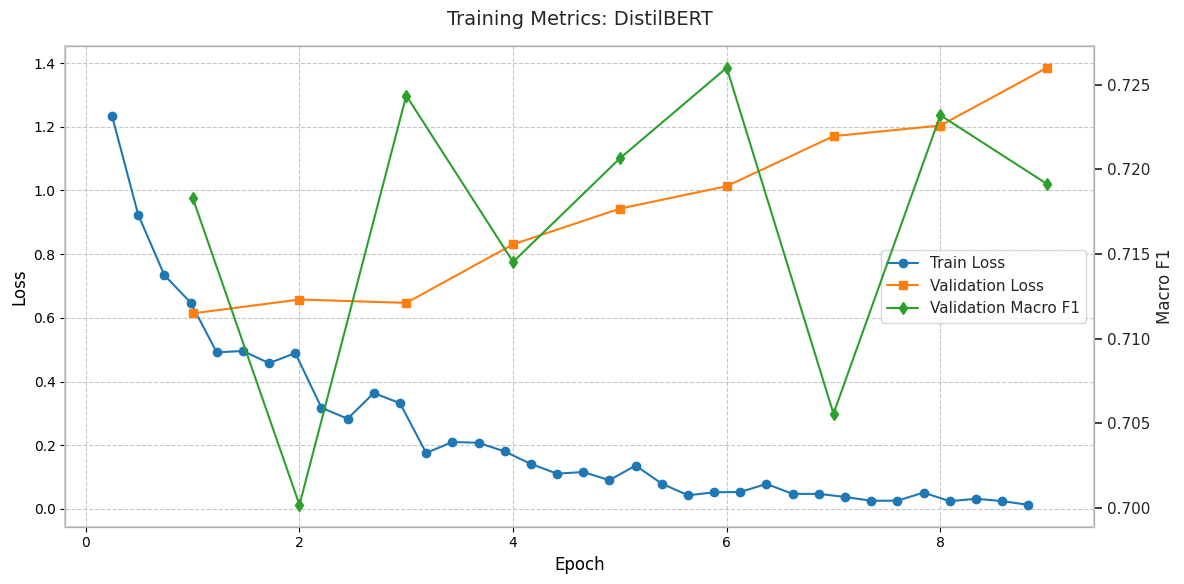

In [10]:
loss_plot(ft_results['distilbert-base-uncased-tweeteval'][0]['Log History'], 'DistilBERT')

In [11]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilroberta-base-tweeteval"] = train_and_evaluate(
    "distilroberta-base",
    train_ds, val_ds, test_ds, test_df,
    "distilroberta-base-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilroberta"
)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:  12%|#2        | 39.9MB /  328MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilroberta-base-tweeteval_StandardTest on provided dataset (size: 1421)...


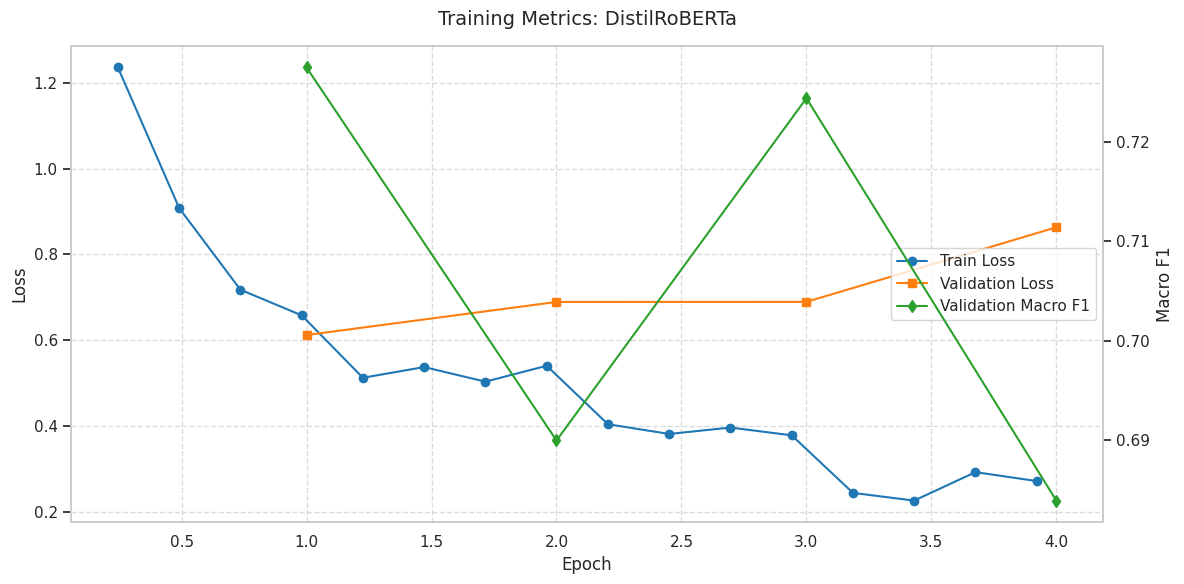

In [12]:
loss_plot(ft_results['distilroberta-base-tweeteval'][0]['Log History'], 'DistilRoBERTa')

In [13]:
final_df = pd.DataFrame({k: v[0] for k, v in ft_results.items()}).T
print(final_df[['Accuracy', 'Macro F1', 'ECE', 'Time/100']].to_string(
    formatters={'Accuracy': '{:,.2%}'.format, 'Macro F1': '{:,.2%}'.format,
                'ECE': '{:.4f}'.format, 'Time/100': '{:.2f}ms'.format}))

                                  Accuracy Macro F1     ECE Time/100
distilbert-base-uncased-tweeteval   79.80%   76.12%  0.1698  74.15ms
distilroberta-base-tweeteval        78.89%   75.06%  0.0421  98.87ms


In [14]:
final_dict = pd.DataFrame(ft_results["distilbert-base-uncased-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.840502,0.782723,0.657407,0.790885,0.79803,0.767879,0.796758
recall,0.840502,0.835196,0.577236,0.772251,0.79803,0.756296,0.798030
f1-score,0.840502,0.808108,0.614719,0.781457,0.79803,0.761196,0.796924
support,558.000000,358.000000,123.000000,382.000000,0.79803,1421.000000,1421.000000


In [15]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.840502 |   0.782723 |   0.657407 |   0.790885 |    0.79803 |    0.767879 |       0.796758 |\n| recall    |   0.840502 |   0.835196 |   0.577236 |   0.772251 |    0.79803 |    0.756296 |       0.79803  |\n| f1-score  |   0.840502 |   0.808108 |   0.614719 |   0.781457 |    0.79803 |    0.761196 |       0.796924 |\n| support   | 558        | 358        | 123        | 382        |    0.79803 | 1421        |    1421        |'

In [16]:
final_dict = pd.DataFrame(ft_results["distilroberta-base-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.787440,0.755668,0.833333,0.821752,0.788881,0.799548,0.792632
recall,0.876344,0.837989,0.487805,0.712042,0.788881,0.728545,0.788881
f1-score,0.829517,0.794702,0.615385,0.762973,0.788881,0.750644,0.784322
support,558.000000,358.000000,123.000000,382.000000,0.788881,1421.000000,1421.000000


In [17]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.78744  |   0.755668 |   0.833333 |   0.821752 |   0.788881 |    0.799548 |       0.792632 |\n| recall    |   0.876344 |   0.837989 |   0.487805 |   0.712042 |   0.788881 |    0.728545 |       0.788881 |\n| f1-score  |   0.829517 |   0.794702 |   0.615385 |   0.762973 |   0.788881 |    0.750644 |       0.784322 |\n| support   | 558        | 358        | 123        | 382        |   0.788881 | 1421        |    1421        |'

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

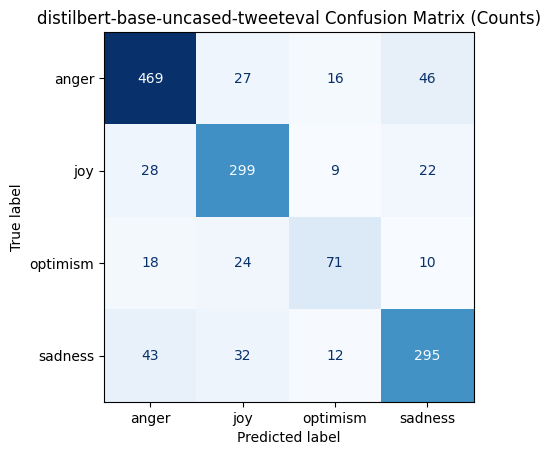

<Figure size 600x600 with 0 Axes>

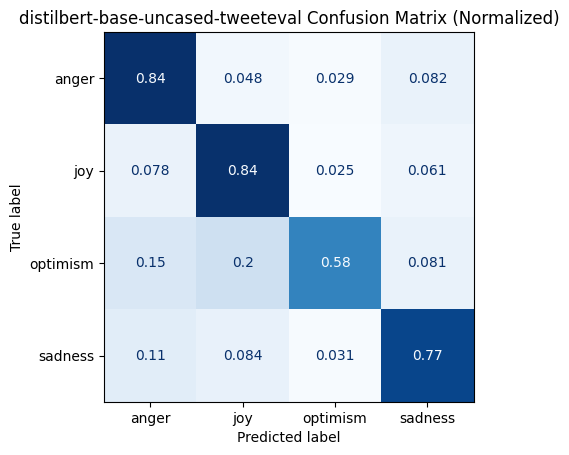

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

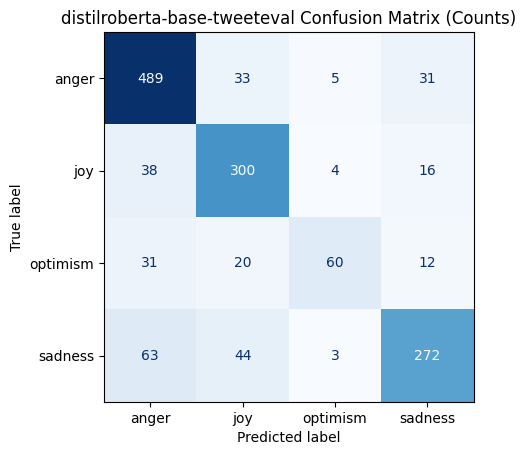

<Figure size 600x600 with 0 Axes>

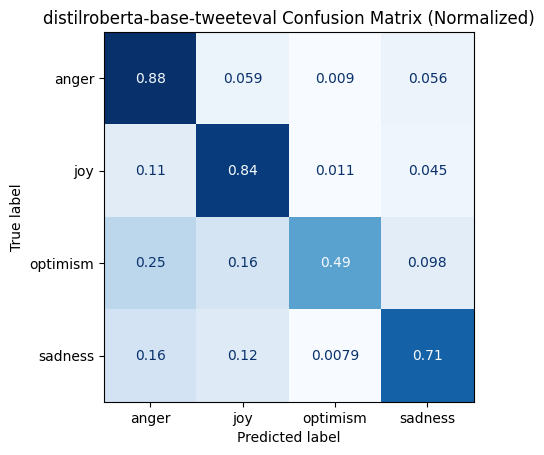

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcdefaults()
plt.style.use("default")
plt.rcParams["axes.grid"] = False

y_true = test_df["label"]
labels_list = list(id_labels.values())

for model_key, (_, trainer, tokenizer) in ft_results.items():

    tokenized_eval = test_ds.map(
        lambda x: tokenizer(x["text"], truncation=True, padding=True),
        batched=True
    )

    preds = trainer.predict(tokenized_eval).predictions
    y_pred = np.argmax(preds, axis=-1)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Counts)")
    plt.show()

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm_norm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Normalized)")
    plt.show()